# NYC Yellow Taxi  

## Group: Fit Happens
## By:  Netanel Rahum & Omer Gabay



**· DSMA 2026 ·**

This notebook
We follow a four-act structure:




| Act | What we do |
|-----|------------|
| [1 -- Data Exploration + Prep ](#act-1)| 
| [2 -- Model Building](#act-2)| Recall what we did In Lectures 1 & 2|
| [3 -- Model Evaluation + Experiments](#act-3) | Performing a train-test split over the data by the exercise instructions |
| [4 -- Productionize Model](#act-4)  | Performing a train-test split over the data by the exercise instructions |

![alt text](image.png)



---



---

| act |  complet   |
|-----|------------|
| 3 -- Recap of Feature engineering | Engineer New features for the ETA prediction task|
| 4 -- Recap of Model Creation | Create Candidate Models for the ETA prediction task |
| 5 -- Recap of Model Evaluation | Evaluate candidates and select champion |
| 6 -- Recap of experiment tracking | Intro to Weights & Biases |
| 7 -- Hyperparameter Tuning | Finding the best "settings" of the model |
| 8 -- Error Tracking | Exploring where the model goes wrong |
| 9 -- Drift Detection | Measuring Data Drift, Label Drift and Concept Drift |
**Dataset:** NYC TLC Yellow Taxi trip records, January 2024

**Goal:** Predicting the **Trip Duration (i.e., how long a trip will take given the pickup location, drop location, distance, and time of pickup)**

In [1]:

import pandas as pd

import joblib
from pathlib import Path

#Act 1
from src.download_data           import run_download_pipeline
from src.validation              import validate_nyc_taxi_data
from src.cleaning                import clean_parquet
# from src.splitting               import split_train_test, subsample_splits # in our project we split the data in the biginning by date and save in sepret folders, so we don't need to split again in the pipeline
from src.features                import run_feature_pipeline, run_baseline_pipeline, TARGET_COL, FEATURE_CREATION_STEPS

#Act 2
from src.models                import train_all_models, load_model, CANDIDATE_MODELS


#act 3
from src.evaluation            import evaluate_all_models, select_champion, plot_feature_importance
# from src.experiment_tracking   import ExperimentTracker, log_monthly_drift_run
# from src.tuning                import (RANDOM_SEARCH_CONFIG, GRID_SEARCH_CONFIGS, run_wandb_sweep, retrain_best_model)
# from src.error_analysis        import run_error_analysis
# from src.drift_detection       import (load_monthly_eval, run_monthly_drift_analysis,
#                                        plot_monthly_mae_curve,
#                                        plot_label_drift_distribution)

# ── Path configuration ────────────────────────────────────────────────────────

RAW_DATA_PARQUET_TEST     = "data/raw/test/" 
RAW_DATA_PARQUET_TRAIN    = "data/raw/train/" 

# RAW_CLEAN_PARQUET    = "data/processed/"
TRAIN_CLEANED_PARQUET = "data/processed/DF_test_2024_2025_cleaned.parquet"
TEST_CLEANED_PARQUET  = "data/processed/Df_test_2026_cleaned.parquet"

# features scaler save path
SCALER_SAVE_PATH_BSSELINE = "data/feature_stores/baseline_scaler.pkl"
SCALER_SAVE_PATH_ENGINEERD = "data/feature_stores/engineered_scaler.pkl"


MODEL_DIR_BASELINE   = "models/baseline"
MODEL_DIR_ENGINEERED = "models/engineered"
MODEL_DIR_TUNED      = "models/tuned"
MODEL_DIR_MITIGATED  = "models/mitigated"
PLOTS_DIR            = "outputs/plots"
MONTHLY_EVAL_PARQUET = "data/raw/last_weeks_all_months_2024.parquet"

# ── W&B configuration ─────────────────────────────────────────────────────────

# WANDB_PROJECT = "CHACK WHAT THE REAL NAME IS"  --------->לברר איך להגדיר נכון



# ── Helpers ───────────────────────────────────────────────────────────────────

def _print_header(title):
    print("\n" + "=" * 60)
    print(title)
    print("=" * 60)



### What does one row represent?

A single row encodes the full lifecycle of one metered taxi trip:

| Column group | What it captures |
|---|---|
| `VendorID` | Which company's hardware recorded this trip |
| `tpep_pickup/dropoff_datetime` | When the trip started and ended |
| `PULocationID / DOLocationID` | Pickup and dropoff taxi zones (1-265) |
| `passenger_count`, `trip_distance` | Trip characteristics |
| `fare_amount`, `tip_amount`, `total_amount` | The money |
| `RatecodeID`, `payment_type` | How the fare was calculated and paid |
| `mta_tax`, `improvement_surcharge`, `congestion_surc### What does one row represent?

Each row in the dataset represents a **single completed trip by a Yellow Taxi in New York City**. 
The cleaned dataset contains only "valid" trips: starting from December 2023 onwards, with no critical missing data, logical distances and times (the drop-off time is strictly after the pick-up time), and a minimum base fare of $3.00.

#### Relevant Columns (Features & Targets)
The following columns were selected as relevant for the Feature Engineering process and modeling, based on the project's data dictionary and business logic:

| Column Name | Data Type | Description (per Data Dictionary) | Relevance to the Project |
| :--- | :--- | :--- | :--- |
| **`tpep_pickup_datetime`** | `datetime` | The exact date and time when the meter was engaged. | Critical for ETA calculation and extracting temporal features (e.g., hour of day, day of week). |
| **`tpep_dropoff_datetime`** | `datetime` | The exact date and time when the meter was disengaged. | Used to calculate the target variable (total trip duration). |
| **`trip_distance`** | `float` | The elapsed trip distance in miles reported by the taximeter. | Essential spatial feature for predicting trip duration or fare. |
| **`PULocationID`** | `int` | TLC Taxi Zone in which the taximeter was engaged (Pickup). | Essential spatial feature. |
| **`DOLocationID`** | `int` | TLC Taxi Zone in which the taximeter was disengaged (Dropoff). | Essential spatial feature. |
| **`RatecodeID`** | `int` | The final rate code in effect at the end of the trip (e.g., 1=Standard rate, 2=JFK). | Used for further analysis of trip types. |
| **`payment_type`** | `int` | How the passenger paid for the trip (1=Credit card, 2=Cash, etc.). | Used for analysis and business logic validation (e.g., ensuring no cash tips are recorded). |
| **`fare_amount`** | `float` | The time-and-distance fare calculated by the meter. | Used for validation (must be at least the $3.00 base fare). |
| **`total_amount`** | `float` | The total amount charged to the passenger. | Used for data validation filters. |
| **`tip_amount`** | `float` | Tip amount (automatically populated for credit card tips only). | Kept for potential secondary target calculation or analysis. |
harge` | Fixed regulatory add-ons |


> **Looking at `.describe()`**  -- what values look suspicious to you before we even run a single validation check?

# Act 1 - Data Exploration + Prep 
<a id="act-1"></a>


| section | What we do |
| :--- | :--- |
| [1.1 -- Data download configuration & Splitting](#section-1-1) | Downloading the data, and splitting it into training and test folders |
| [1.2 -- Fundamentals](#section-1-2) | Understand the shape and meaning of the data |
| [1.3 -- Data Validation](#section-1-3) | Ask systematic questions: does the data meet our expectations? |
| [1.4 -- Data Cleaning](#section-1-4) | produce a clean dataframe ready for analysis. |
| [1.5 -- Feature engineering](#section-1-5) | produce a clean dataframe ready for analysis. |



<a id="section-1-1"></a>
## 1.1 -- Data download configuration & Splitting


In [2]:
run_download_pipeline()

print("Data download step finished.")

INITIALIZING NYC TLC DATA SYNC PIPELINE
  [EXISTS] yellow_tripdata_2024-01.parquet is already locally available.
           URL: https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet
  [EXISTS] yellow_tripdata_2024-03.parquet is already locally available.
           URL: https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-03.parquet
  [EXISTS] yellow_tripdata_2025-01.parquet is already locally available.
           URL: https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2025-01.parquet
PIPELINE EXECUTION COMPLETE
Execution Summary: Successfully verified 3/3 partitions.
Target Directories:
  - TRAIN: 'data/raw\train/'
  - TEST: 'data/raw\test/'
Data download step finished.


<a id="section-1-2"></a>
## 1.2 Fundamentals 

In [3]:
df_row_test  = pd.read_parquet(str(RAW_DATA_PARQUET_TEST) , engine='pyarrow')
df_row_train = pd.read_parquet(str(RAW_DATA_PARQUET_TRAIN), engine='pyarrow')

print("-" * 30 + " RAW DATA OVERVIEW " + "-" * 30)


print("-" * 20 + "      TRAIN DATA   " + "-" * 20)
print(f'Loaded {len(df_row_train):,} rows x {df_row_train.shape[1]} columns')
df_row_train.info()


print("-" * 60)

print("-" * 20 + "      test DATA     " + "-" * 20)
print(f'Loaded {len(df_row_test):,} rows x {df_row_test.shape[1]} columns')
df_row_test.info()

------------------------------ RAW DATA OVERVIEW ------------------------------
--------------------      TRAIN DATA   --------------------
Loaded 6,547,252 rows x 19 columns
<class 'pandas.DataFrame'>
RangeIndex: 6547252 entries, 0 to 6547251
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64

In [4]:
df_row_train.head(5)
# df_row_test.head(5)



,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,N,186,79,2,17.7,1.0,0.5,0.00,0.0,1.0,22.70,2.5,0.0
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,N,140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,N,236,79,1,23.3,3.5,0.5,3.00,0.0,1.0,31.30,2.5,0.0
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,1.0,N,79,211,1,10.0,3.5,0.5,2.00,0.0,1.0,17.00,2.5,0.0
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,1.0,N,211,148,1,7.9,3.5,0.5,3.20,0.0,1.0,16.10,2.5,0.0


In [5]:
# Summary statistics for every numeric column
# Look for: surprising min/max values, large std relative to mean, suspicious zeros
df_row_train.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
count,6.547252e+06,6547252,6547252,5.980900e+06,6.547252e+06,5.980900e+06,6.547252e+06,6.547252e+06,6.547252e+06,6.547252e+06,6.547252e+06,6.547252e+06,6.547252e+06,6.547252e+06,6.547252e+06,6.547252e+06,5.980900e+06,5.980900e+06
mean,1.756355e+00,2024-02-18 14:37:33.197204,2024-02-18 14:53:44.766711,1.338407e+00,4.125626e+00,2.167760e+00,1.650289e+02,1.640440e+02,1.114727e+00,1.845274e+01,1.403626e+00,4.830726e-01,3.256490e+00,5.349695e-01,9.748958e-01,2.697610e+01,2.254147e+00,1.418916e-01
min,1.000000e+00,2002-12-31 22:17:10,2002-12-31 22:42:24,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,-8.990000e+02,-7.500000e+00,-5.000000e-01,-3.000000e+02,-8.430000e+01,-1.000000e+00,-9.000000e+02,-2.500000e+00,-1.750000e+00
25%,2.000000e+00,2024-01-18 17:57:38,2024-01-18 18:13:51.750000,1.000000e+00,1.000000e+00,1.000000e+00,1.320000e+02,1.140000e+02,1.000000e+00,8.600000e+00,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.545000e+01,2.500000e+00,0.000000e+00
50%,2.000000e+00,2024-03-03 17:28:55.500000,2024-03-03 17:47:46.500000,1.000000e+00,1.700000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.280000e+01,1.000000e+00,5.000000e-01,2.600000e+00,0.000000e+00,1.000000e+00,2.022000e+01,2.500000e+00,0.000000e+00
75%,2.000000e+00,2024-03-17 14:24:17.250000,2024-03-17 14:41:27,1.000000e+00,3.210000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,2.120000e+01,2.500000e+00,5.000000e-01,4.100000e+00,0.000000e+00,1.000000e+00,2.904000e+01,2.500000e+00,0.000000e+00
max,6.000000e+00,2024-04-01 00:34:55,2024-04-02 18:08:46,9.000000e+00,3.127223e+05,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,5.000000e+03,1.425000e+01,3.584000e+01,9.999900e+02,1.630000e+02,1.000000e+00,5.000000e+03,2.500000e+00,1.750000e+00
std,4.318350e-01,NaN,NaN,8.448871e-01,2.702968e+02,1.028344e+01,6.409494e+01,6.946155e+01,6.195190e-01,1.850228e+01,1.807193e+00,1.196424e-01,3.972404e+00,2.144226e+00,2.209202e-01,2.308505e+01,8.309926e-01,4.898178e-01


<a id="section-1-3"></a>
## 1.3 Data Validation

In [6]:
# from src.validation import validate_nyc_taxi_parquet

report   = validate_nyc_taxi_data(df_row_train)
passed_n = sum(r['passed'] for r in report['results'])
total_n  = len(report['results'])
status   = 'ALL PASSED' if report['success'] else 'SOME CHECKS FAILED'
print(f'Result: {status}  ({passed_n}/{total_n} checks passed)')

Result: SOME CHECKS FAILED  (10/12 checks passed)


In [7]:
# Full results table
print('{:<4} {:<32} {:<48} {}'.format('#', 'Column', 'Check', 'Result'))
print('-' * 95)
for i, r in enumerate(report['results'], 1):
    col    = r['column']
    name   = r['name']
    icon   = 'OK  ' if r['passed'] else 'FAIL'
    print('{:<4} {:<32} {:<48} {}'.format(i, col, name, icon))
    if not r['passed']:
        detail = r['detail']
        print(f'     >> {detail}')

#    Column                           Check                                            Result
-----------------------------------------------------------------------------------------------
1    tpep_pickup_datetime             not_null                                         OK  
2    tpep_dropoff_datetime            not_null                                         OK  
3    tpep_pickup_datetime, tpep_dropoff_datetime tpep_dropoff_datetime_geq_tpep_pickup_datetime   FAIL
     >> 0.00% of rows violate ordering constraint (tpep_dropoff_datetime < tpep_pickup_datetime)
4    PULocationID                     not_null                                         OK  
5    PULocationID                     between[1,265]                                   OK  
6    DOLocationID                     not_null                                         OK  
7    DOLocationID                     between[1,265]                                   OK  
8    trip_distance                    between[0.0,None]   

<a id="section-1-4"></a>
## 1.4 Data Cleaning

In [8]:
print("--- Cleaning TRAIN Data ---")
df_clean_train = clean_parquet(DF_not_clean=df_row_train,output_path=TRAIN_CLEANED_PARQUET, is_train=True)

print("\n--- Cleaning TEST Data ---")
df_clean_test  = clean_parquet(DF_not_clean=df_row_test, output_path=TEST_CLEANED_PARQUET, is_train=False)

print("\n" + "="*40)
print(f"Train shape after cleaning: {df_clean_train.shape}")
print(f"Test shape after cleaning:  {df_clean_test.shape}")
print("="*40)

--- Cleaning TRAIN Data ---

STARTING CLEANING PIPELINE
Loading data from DF...
Processing DataFrame...
  Input  rows : 6,547,252
  drop_critical_nulls  : no rows dropped
  drop_pre_december_2023  : dropped 7 rows
  fill_non_critical_nulls : filled - RatecodeID (566,352 -> 1), store_and_fwd_flag (566,352 -> 'N'), Airport_fee (566,352 -> 0.0)
  select_relevant_columns : dropped 9 columns - ['VendorID', 'passenger_count', 'store_and_fwd_flag', 'extra', 'mta_tax', 'tolls_amount', 'improvement_surcharge', 'congestion_surcharge', 'Airport_fee']
  drop_remaining_nulls : no remaining nulls
  filter_temporal_logic   : dropped 173 invalid rows
  filter_monetary_logic   : dropped 110,125 invalid rows
  Output rows : 6,436,947
  Saved cleaned file -> data/processed/DF_test_2024_2025_cleaned.parquet


--- Cleaning TEST Data ---

STARTING CLEANING PIPELINE
Loading data from DF...
Processing DataFrame...
  Input  rows : 3,475,226
  fill_non_critical_nulls : filled - RatecodeID (540,149 -> 1), store_

In [9]:
df_clean_train.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,PULocationID,DOLocationID,RatecodeID,payment_type,fare_amount,total_amount,tip_amount
0,2024-01-01 00:57:55,2024-01-01 01:17:43,1.72,186,79,1.0,2,17.7,22.70,0.00
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.80,140,236,1.0,1,10.0,18.75,3.75
2,2024-01-01 00:17:06,2024-01-01 00:35:01,4.70,236,79,1.0,1,23.3,31.30,3.00
3,2024-01-01 00:36:38,2024-01-01 00:44:56,1.40,79,211,1.0,1,10.0,17.00,2.00
4,2024-01-01 00:46:51,2024-01-01 00:52:57,0.80,211,148,1.0,1,7.9,16.10,3.20


<a id="section-1-5"></a>

## 1.5  Feature engineering

In [10]:
# ══════════════════════════════════════════════════════════════════════════
# EXPERIMENT A — Baseline (raw features only)
# ══════════════════════════════════════════════════════════════════════════

_print_header("STEP 3 — Experiment A: Baseline (Raw Features Only)")

baseline_train, baseline_scaler = run_baseline_pipeline(df_clean_train, is_training=True, scaler_save_path=SCALER_SAVE_PATH_BSSELINE)
X_train_base = baseline_train.drop(columns=[TARGET_COL])
y_train_base = baseline_train[TARGET_COL]
print(f"  Baseline feature columns ({len(X_train_base.columns)}): " f"{X_train_base.columns.tolist()}")

# train_all_models(X_train_base, y_train_base, MODEL_DIR_BASELINE)

baseline_test,        _        = run_baseline_pipeline(df_clean_test, scaler=baseline_scaler, is_training=False)
X_test_base = baseline_test.drop(columns=[TARGET_COL])
y_test_base = baseline_test[TARGET_COL]

# print("\n  Baseline model results:")
# baseline_results = evaluate_all_models(X_test_base, y_test_base, MODEL_DIR_BASELINE) #-------------------------------------> לשנות את זה אחר כך


# ══════════════════════════════════════════════════════════════════════════
print("\n" + "~"*18)
print("X_train_base sample:")
print("~"*18)

display(X_train_base.head(500))

print("\n" + "-"*25)

print("\n" + "~"*18)
print("y_train_base sample:")
print("~"*18)
display(y_train_base.head(6))

# display(X_train_base['pickup_hour'].value_counts().sort_index()) # to check if the values are in the right order (0-23) and if the distribution makes sense
# display(X_train_base['day_of_week'].value_counts().sort_index()) # to check if the values are in the right order (0-6) and if the distribution makes sense




STEP 3 — Experiment A: Baseline (Raw Features Only)
  Saved baseline scaler -> data/feature_stores/baseline_scaler.pkl
  Baseline feature columns (5): ['trip_distance', 'PULocationID', 'DOLocationID', 'pickup_hour', 'day_of_week']

~~~~~~~~~~~~~~~~~~
X_train_base sample:
~~~~~~~~~~~~~~~~~~


,trip_distance,PULocationID,DOLocationID,pickup_hour,day_of_week
0,-0.008849,186,79,-2.452811,-1.585518
1,-0.008551,140,236,-2.452811,-1.585518
2,0.002240,236,79,-2.452811,-1.585518
3,-0.010039,79,211,-2.452811,-1.585518
4,-0.012272,211,148,-2.452811,-1.585518
...,...,...,...,...,...
495,-0.001481,148,237,-2.452811,-1.585518
496,-0.004867,142,166,-2.452811,-1.585518
497,-0.011900,166,238,-2.452811,-1.585518
498,-0.011826,238,75,-2.452811,-1.585518



-------------------------

~~~~~~~~~~~~~~~~~~
y_train_base sample:
~~~~~~~~~~~~~~~~~~


0    22.7
1    15.0
2    28.3
3    15.0
4    12.9
5    34.6
Name: total_fare_amount, dtype: float64

In [11]:
# ══════════════════════════════════════════════════════════════════════════
# EXPERIMENT B — Full Feature Engineering
# ══════════════════════════════════════════════════════════════════════════

_print_header("STEP 4 — Experiment B: Full Feature Engineering")

eng_train, eng_scaler = run_feature_pipeline(df_clean_train, is_training=True, scaler_save_path=SCALER_SAVE_PATH_ENGINEERD)
X_train_eng = eng_train.drop(columns=[TARGET_COL])
y_train_eng = eng_train[TARGET_COL]
print(f"  Engineered feature columns ({len(X_train_eng.columns)}): " f"{X_train_eng.columns.tolist()}")


eng_test, _ = run_feature_pipeline(df_clean_test, scaler=eng_scaler, is_training=False)
X_test_eng  = eng_test.drop(columns=[TARGET_COL])
y_test_eng  = eng_test[TARGET_COL]


# Save the fitted scaler so the Streamlit app can load it without rerunning the pipeline
Path(MODEL_DIR_ENGINEERED).mkdir(parents=True, exist_ok=True)
joblib.dump(eng_scaler, Path(MODEL_DIR_ENGINEERED) / "scaler.pkl")
print(f"  Scaler saved → {MODEL_DIR_ENGINEERED}/scaler.pkl")


# ══════════════════════════════════════════════════════════════════════════
print("\n" + "~"*18)
print("X_train_base sample:")
print("~"*18)

display(X_train_eng.head(500))

print("\n" + "-"*25)

print("\n" + "~"*18)
print("y_train_base sample:")
print("~"*18)
display(y_train_eng.head(6))

# display(X_train_eng['pickup_hour'].value_counts().sort_index()) # to check if the values are in the right order (0-23) and if the distribution makes sense
# display(X_train_eng['day_of_week'].value_counts().sort_index()) # to check if the values are in the right order (0-6) and if the distribution makes sense
# display(X_train_eng['is_weekend'].value_counts().sort_index()) # to check if the values are in the right order (0-9) and if the distribution makes sense
# display(X_train_eng['is_rush_hour'].value_counts().sort_index()) # to check if the values are in the right order (0-4) and if the distribution makes sense
# display(X_train_eng['time_of_day_bucket'].value_counts().sort_index()) # to check if the values are in the right order and if the distribution makes sense


STEP 4 — Experiment B: Full Feature Engineering
  Saved feature scaler -> data/feature_stores/engineered_scaler.pkl
  Engineered feature columns (17): ['trip_distance', 'PULocationID', 'DOLocationID', 'pickup_hour', 'day_of_week', 'is_weekend', 'is_rush_hour', 'time_of_day_bucket', 'est_base_fare', 'est_congestion_surcharge', 'est_extra', 'est_airport_fee', 'est_improvement_surcharge', 'est_mta_tax', 'est_total_fare_without_tolls', 'pickup_hour_sin', 'pickup_hour_cos']
  Scaler saved → models/engineered/scaler.pkl

~~~~~~~~~~~~~~~~~~
X_train_base sample:
~~~~~~~~~~~~~~~~~~


,trip_distance,PULocationID,DOLocationID,pickup_hour,day_of_week,is_weekend,is_rush_hour,time_of_day_bucket,est_base_fare,est_congestion_surcharge,est_extra,est_airport_fee,est_improvement_surcharge,est_mta_tax,est_total_fare_without_tolls,pickup_hour_sin,pickup_hour_cos
0,-0.008849,186,79,-2.452811,-1.585518,-0.637119,0,-2.129061,-0.009029,0.259018,0.21034,-0.253223,1.0,0.5,-0.009111,0.467326,1.678777
1,-0.008551,140,236,-2.452811,-1.585518,-0.637119,0,-2.129061,-0.008725,0.259018,0.21034,-0.253223,1.0,0.5,-0.008807,0.467326,1.678777
2,0.002240,236,79,-2.452811,-1.585518,-0.637119,0,-2.129061,0.002296,0.259018,0.21034,-0.253223,1.0,0.5,0.002214,0.467326,1.678777
3,-0.010039,79,211,-2.452811,-1.585518,-0.637119,0,-2.129061,-0.010245,0.259018,0.21034,-0.253223,1.0,0.5,-0.010327,0.467326,1.678777
4,-0.012272,211,148,-2.452811,-1.585518,-0.637119,0,-2.129061,-0.012525,0.259018,0.21034,-0.253223,1.0,0.5,-0.012607,0.467326,1.678777
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,-0.001481,148,237,-2.452811,-1.585518,-0.637119,0,-2.129061,-0.001504,0.259018,0.21034,-0.253223,1.0,0.5,-0.001587,0.467326,1.678777
496,-0.004867,142,166,-2.452811,-1.585518,-0.637119,0,-2.129061,-0.004963,0.259018,0.21034,-0.253223,1.0,0.5,-0.005045,0.467326,1.678777
497,-0.011900,166,238,-2.452811,-1.585518,-0.637119,0,-2.129061,-0.012145,0.259018,0.21034,-0.253223,1.0,0.5,-0.012227,0.467326,1.678777
498,-0.011826,238,75,-2.452811,-1.585518,-0.637119,0,-2.129061,-0.012069,0.259018,0.21034,-0.253223,1.0,0.5,-0.012151,0.467326,1.678777



-------------------------

~~~~~~~~~~~~~~~~~~
y_train_base sample:
~~~~~~~~~~~~~~~~~~


0    22.7
1    15.0
2    28.3
3    15.0
4    12.9
5    34.6
Name: total_fare_amount, dtype: float64

<a id="act-2"></a>

# Act 2 - Model Building




| section | What we do |
| :--- | :--- |
| [2.1 -- Model Creation](#section-2-1) | Downloading the data, and splitting it into training and test folders |
| [2.2 -- ~None~](#section-2-2) | Understand the shape and meaning of the data |


<a id="section-2-1"></a>

## 2.1 -- Model Creation

In [12]:
train_all_models(X_train_eng, y_train_eng, MODEL_DIR_ENGINEERED)

  Training linear_regression ... done
  Training random_forest ... done
  Training gradient_boosting ... done


{'linear_regression': LinearRegression(),
 'random_forest': RandomForestRegressor(max_depth=10, max_samples=0.1, min_samples_leaf=50,
                       n_estimators=50, n_jobs=-1, random_state=42),
 'gradient_boosting': HistGradientBoostingRegressor(max_depth=5, min_samples_leaf=50, random_state=42)}

In [13]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 5 — Head-to-head comparison
# ══════════════════════════════════════════════════════════════════════════

# _print_header("STEP 5 — Feature Engineering Impact: Head-to-Head Comparison")
# print("  Metric: MAE (minutes).  Lower is better.")
# print("  Improvement = % reduction in MAE achieved by feature engineering.\n")
# comparison = _comparison_table(baseline_results, engineered_results)

# best_model_row = comparison.loc[comparison["mae_improvement_%"].idxmax()]
# print(
#     f"\n  Largest gain : {best_model_row['model']} "
#     f"improved by {best_model_row['mae_improvement_%']:.1f}% with feature engineering"
# )

# ── Step 6: Champion + Feature Importance + W&B (via ExperimentTracker) ───
# _print_header("STEP 6 — Champion Model + Feature Importance")
# champion_name  = select_champion(engineered_results, metric="mae")
# champion_model = load_model(champion_name, MODEL_DIR_ENGINEERED)
# champion_row   = engineered_results.loc[
#     engineered_results["model"] == champion_name
# ].iloc[0]

# plot_feature_importance(
#     model         = champion_model,
#     feature_names = X_test_eng.columns.tolist(),
#     model_name    = champion_name,
#     output_dir    = PLOTS_DIR,
# )

# tracker = ExperimentTracker(
#     project  = wandb_project,
#     run_name = "champion-eval",
#     tags     = ["champion", "engineered-features"],
#     config   = {"champion_model": champion_name},
# )
# tracker.log_summary({
#     "champion_model": champion_name,
#     "mae":            float(champion_row["mae"]),
#     "rmse":           float(champion_row["rmse"]),
#     "mape":           float(champion_row["mape"]),
# })
# Log feature importance plot saved to disk
# fi_path = Path(PLOTS_DIR) / f"feature_importance_{champion_name}.png"
# if fi_path.exists():
#     tracker.log_image_file(fi_path, "feature_importance")
# tracker.log_code()
# url = tracker.finish()
# print(f"\n  W&B run logged → {url}")


Evaluating engineered models on test set...

  Model                         RMSE      MAE     MAPE
  -----------------------------------------------------
  gradient_boosting           463.29     4.21    27.8%
  linear_regression           463.42    10.30    58.7%
  random_forest               463.29     4.30    28.5%


,model,rmse,mae,mape
0,gradient_boosting,463.2858,4.2081,27.8031
1,random_forest,463.2871,4.2994,28.5271
2,linear_regression,463.4234,10.2990,58.6567



  Champion model : gradient_boosting
  MAE            : 4.2081
  Computing permutation feature importance (using 5,000 samples for speed)...
  Plot saved -> outputs\plots\feature_importance_gradient_boosting.png


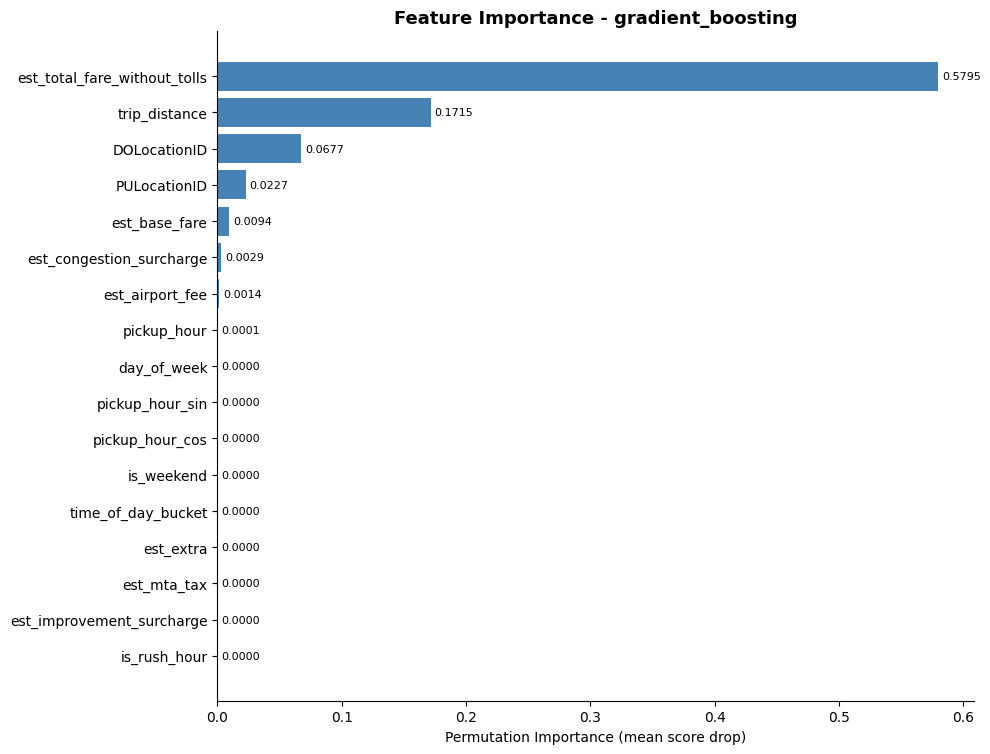

,feature,importance
6,is_rush_hour,0.000000e+00
12,est_improvement_surcharge,0.000000e+00
13,est_mta_tax,0.000000e+00
10,est_extra,0.000000e+00
7,time_of_day_bucket,0.000000e+00
5,is_weekend,0.000000e+00
16,pickup_hour_cos,0.000000e+00
15,pickup_hour_sin,3.973061e-07
4,day_of_week,5.494494e-06
3,pickup_hour,5.148271e-05


In [14]:
# # 1. ייבוא
# from src.evaluation import evaluate_all_models, select_champion, plot_feature_importance
# from src.models import load_model

# 2. הרצת הערכה 
print("Evaluating engineered models on test set...")
eng_results = evaluate_all_models(X_test_eng, y_test_eng, MODEL_DIR_ENGINEERED)
display(eng_results)

# 3. בחירת המודל המנצח
champion_name = select_champion(eng_results, metric="mae")
champion_model = load_model(champion_name, MODEL_DIR_ENGINEERED)

# 4. ציור חשיבות הפיצ'רים עם Permutation Importance
plot_feature_importance(
    model=champion_model,
    feature_names=X_test_eng.columns.tolist(),
    model_name=champion_name,
    X_val=X_test_eng,             # <--- הוספנו את הפיצ'רים לבדיקה
    y_val=y_test_eng,             # <--- הוספנו את הטרגט לבדיקה
    output_dir=PLOTS_DIR
)


# Act 3 - Model Evaluation + Experiments
<a id="act-3"></a>

| section | What we do |
| :--- | :--- |
| [2.1 -- ~BLA BLA1~](#section-3-1) | BLA BLA BLLA BLA |
| [2.2 -- ~BLA BLA2~](#section-3-2) | BLA BLA BLA :( |


<a id="act-4"></a>

# Act 4 - Productionize Model

| section | What we do |
| :--- | :--- |
| [2.1 -- ~BLA BLA1~](#section-4-1) | BLA BLA ＜（＾－＾）＞ |
| [2.2 -- ~BLA BLA2~](#section-4-2) | BLA BLA φ(*￣0￣) |
